# XAI Analysis: Explanation Methods Comparison
comparing gradient saliency, integrated gradients, LIME, and attention rollout
on the trained multi-task ViT

In [1]:
import sys
sys.path.insert(0, '..')

import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.config import SALICON_DIR, COCO_ANN_DIR, NUM_LABELS, RUNS_DIR, DEVICE, GRID_SIZE
from src.data.salicon_coco import SaliconCocoDataset
from src.data.transforms import build_image_transform, SaliencyTransform
from src.models.vit_multitask import build_model
from src.utils.io import load_checkpoint
from src.utils.viz import denormalize_image, plot_explanation_comparison

In [2]:
# load model
model, _ = build_model(mode='multitask', num_labels=NUM_LABELS, pretrained=False)
load_checkpoint(model, RUNS_DIR / 'best_multitask.pt')
model = model.to(DEVICE)
model.eval()

# load val data
img_tfm = build_image_transform(train=False)
sal_tfm = SaliencyTransform()
train_ds = SaliconCocoDataset(
    img_dir=SALICON_DIR / 'images' / 'train',
    saliency_dir=SALICON_DIR / 'train',
    coco_ann_path=COCO_ANN_DIR / 'instances_train2014.json',
    split_prefix='COCO_train2014',
    img_tfm=img_tfm, sal_tfm=sal_tfm, k_labels=NUM_LABELS,
)
val_ds = SaliconCocoDataset(
    img_dir=SALICON_DIR / 'images' / 'val',
    saliency_dir=SALICON_DIR / 'val',
    coco_ann_path=COCO_ANN_DIR / 'instances_val2014.json',
    split_prefix='COCO_val2014',
    img_tfm=img_tfm, sal_tfm=sal_tfm, k_labels=NUM_LABELS,
    cat_to_idx=train_ds.cat_to_idx,
    cat_names=train_ds.cat_names,
)
print(f'val samples: {len(val_ds)}')

loaded checkpoint from /home/nick/projects/xai/project1/runs/best_multitask.pt, epoch 1
val samples: 5000


In [3]:
from src.xai.gradient_saliency import compute_gradient_saliency, compute_grad_x_input
from src.xai.ig_explain import integrated_gradients
from src.xai.lime_explain import lime_explain
from src.xai.attention_rollout import attention_rollout
from src.xai.human_alignment import resize_to_grid

# pick a sample
idx = 42
sample = val_ds[idx]
image = sample['image'].unsqueeze(0)

# get top predicted class
with torch.no_grad():
    logits, sal_pred = model(image.to(DEVICE))
    probs = torch.sigmoid(logits[0])
target_class = int(probs.argmax().item())
print(f'target class: {train_ds.cat_names[target_class]} (prob: {probs[target_class]:.3f})')

/home/nick/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


target class: dining table (prob: 0.943)


  0%|          | 0/300 [00:00<?, ?it/s]

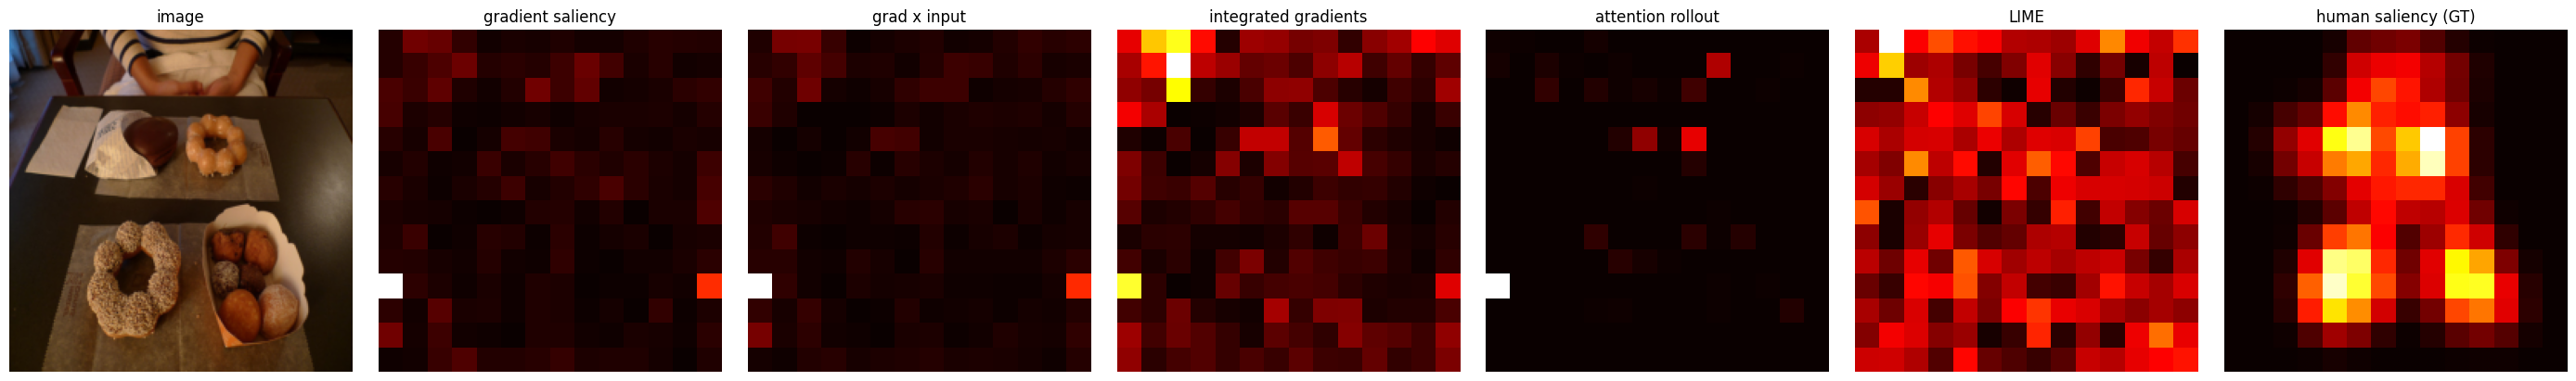

In [4]:
# generate all explanations
grad_sal = resize_to_grid(compute_gradient_saliency(model, image, target_class, DEVICE))
grad_inp = resize_to_grid(compute_grad_x_input(model, image, target_class, DEVICE))
ig = resize_to_grid(integrated_gradients(model, image, target_class, DEVICE, steps=50))
rollout = attention_rollout(model, image, DEVICE)
lime_map = lime_explain(model, image, target_class, DEVICE, num_samples=300)

# compare side by side
explanations = [grad_sal, grad_inp, ig, rollout, lime_map, sample['sal_grid'].squeeze().numpy()]
titles = ['gradient saliency', 'grad x input', 'integrated gradients',
          'attention rollout', 'LIME', 'human saliency (GT)']

plot_explanation_comparison(sample['image'], explanations, titles)

In [5]:
# load full xai results
with open(RUNS_DIR / 'xai_results.json') as f:
    xai_results = json.load(f)

# print summary table
print(f'{"method":<25} {"del AUC":>10} {"ins AUC":>10} {"align CC":>10} {"align SIM":>10}')
print('-' * 65)
for method, res in xai_results.items():
    print(f'{method:<25} {res["deletion_auc_mean"]:>10.4f} {res["insertion_auc_mean"]:>10.4f} '
          f'{res["alignment_CC_mean"]:>10.4f} {res["alignment_SIM_mean"]:>10.4f}')

method                       del AUC    ins AUC   align CC  align SIM
-----------------------------------------------------------------
gradient_saliency             0.4682     0.7658     0.1611     0.4104
grad_x_input                  0.5213     0.7675     0.1714     0.4053
integrated_gradients          0.4786     0.7783     0.2480     0.4342
attention_rollout             0.5444     0.7446    -0.0030     0.1231
lime                          0.4086     0.8814     0.1075     0.4156



xai_faithfulness_alignment.png:


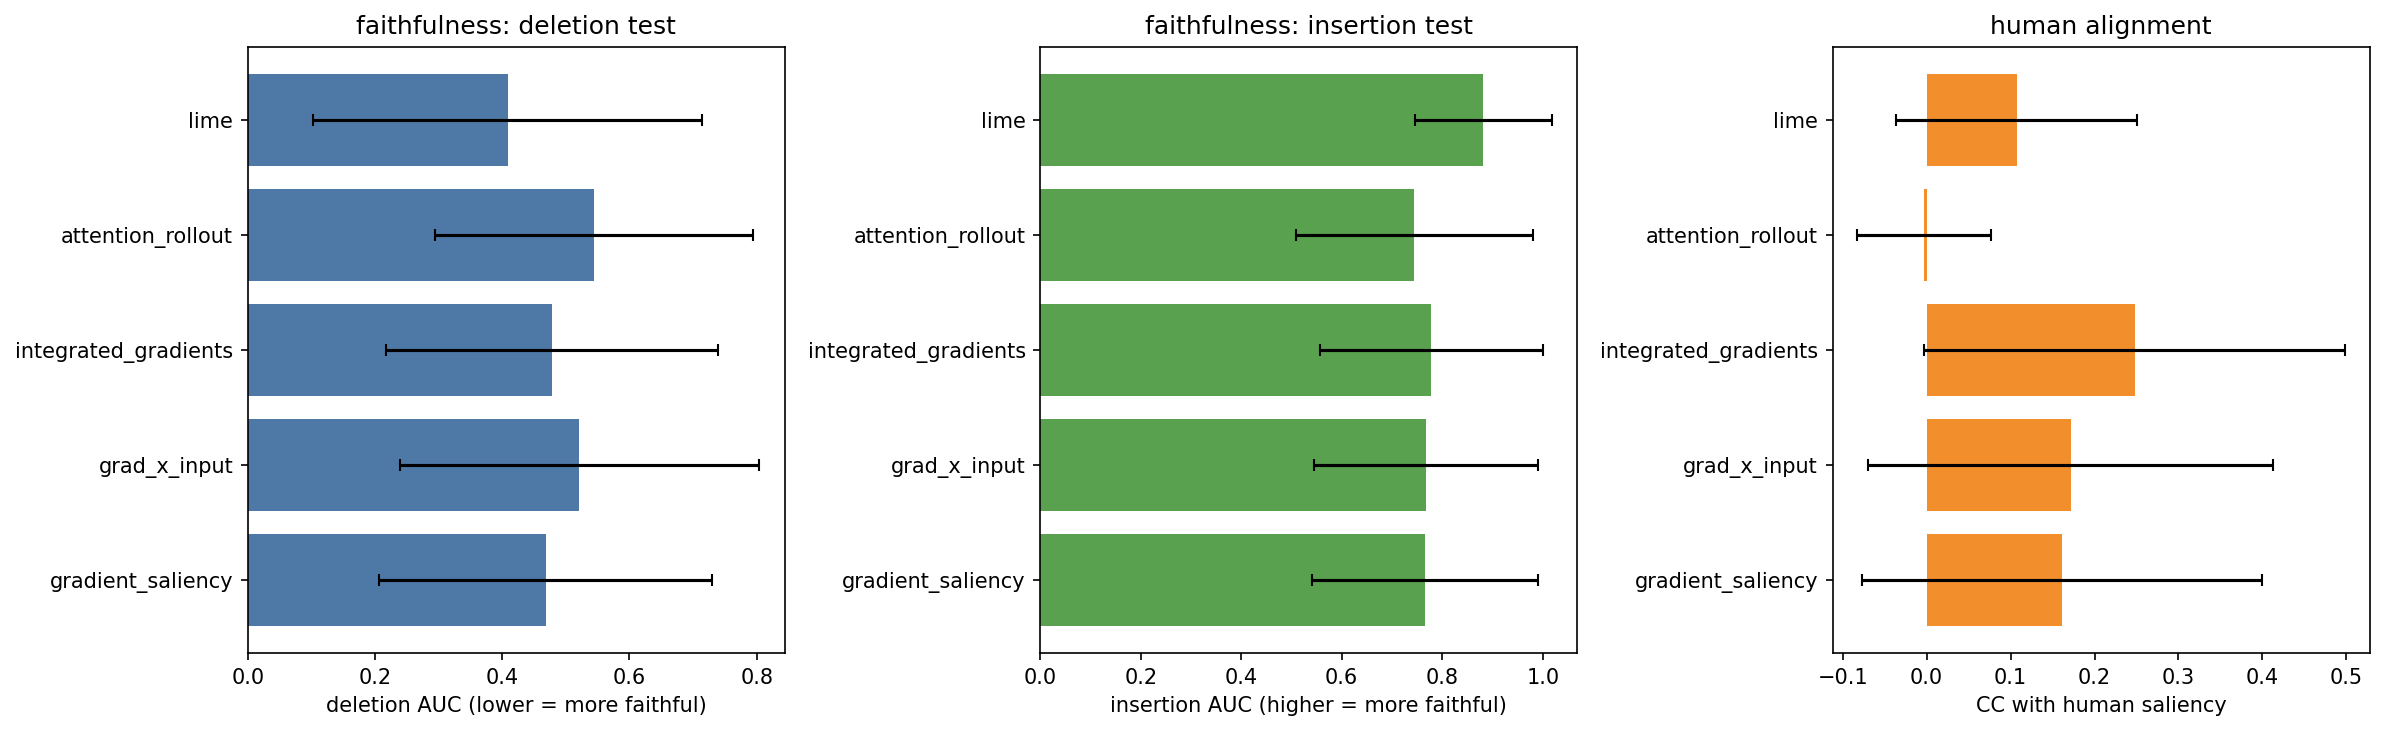


xai_stability.png:


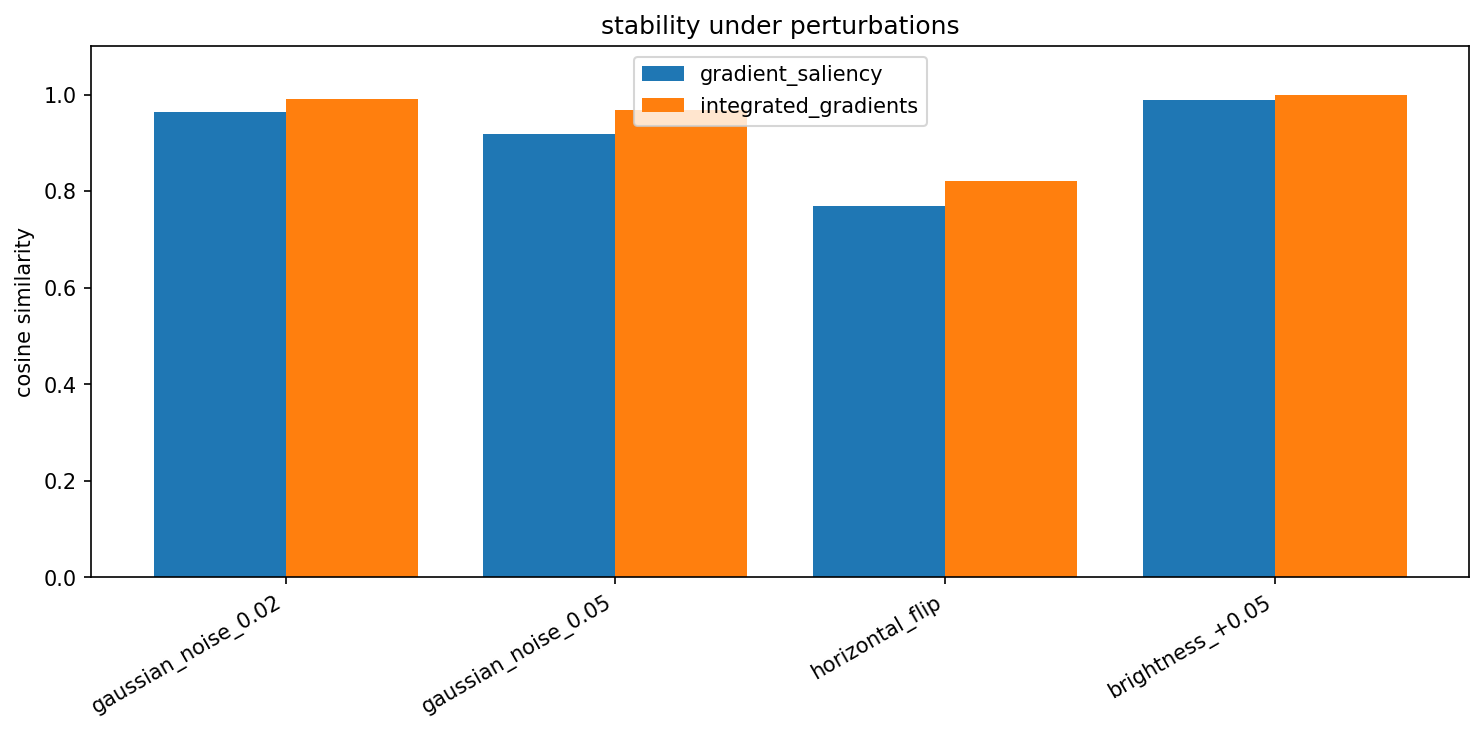

In [6]:
# load and display pre-generated figures
from IPython.display import Image, display
figures_dir = RUNS_DIR / 'figures'

for fig_name in ['xai_faithfulness_alignment.png', 'xai_stability.png']:
    fig_path = figures_dir / fig_name
    if fig_path.exists():
        print(f'\n{fig_name}:')
        display(Image(filename=str(fig_path)))